## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv("Ejercicio 2.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


In [4]:
# Dataset analysis
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
display(df["Exited"].value_counts())
display(df["Exited"].value_counts(normalize=True).round(3))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset shape: (9001, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB

Missing values per column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicated rows:
2

Target distribution:


Exited
0    7161
1    1840
Name: count, dtype: int64

Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,9001.0,NaN,NaN,NaN,5003.366515,2884.787499,2.0,2509.0,4989.0,7505.0,10000.0
CustomerId,9001.0,NaN,NaN,NaN,15690724.66126,71793.534227,15565701.0,15628112.0,15690958.0,15752650.0,15815690.0
Surname,9001,2772,Smith,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,9001.0,NaN,NaN,NaN,650.681369,96.539591,350.0,584.0,652.0,718.0,850.0
Geography,9000,3,France,4505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,9001,2,Male,4906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,9000.0,NaN,NaN,NaN,38.901781,10.45076,18.0,32.0,37.0,44.0,92.0
Tenure,9001.0,NaN,NaN,NaN,5.007888,2.894025,0.0,2.0,5.0,7.0,10.0
Balance,9001.0,NaN,NaN,NaN,76222.210827,62432.198151,0.0,0.0,96997.09,127450.14,250898.09
NumOfProducts,9001.0,NaN,NaN,NaN,1.531497,0.579398,1.0,1.0,1.0,2.0,4.0


In [5]:
# review categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False))

Categorical columns: ['Surname', 'Geography', 'Gender']

Surname


Surname
Smith          29
Yeh            25
Martin         25
Walker         24
Genovese       23
               ..
Beit            1
Onwuamaegbu     1
Edith           1
Holder          1
Macrossan       1
Name: count, Length: 2772, dtype: int64


Geography


Geography
France     4505
Spain      2250
Germany    2245
NaN           1
Name: count, dtype: int64


Gender


Gender
Male      4906
Female    4095
Name: count, dtype: int64

In [6]:
# review binary variables
binary_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 2]
print("Binary columns:", binary_cols)

for col in binary_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False))

Binary columns: ['Gender', 'IsActiveMember', 'Exited']

Gender


Gender
Male      4906
Female    4095
Name: count, dtype: int64


IsActiveMember


IsActiveMember
1.0    4633
0.0    4368
Name: count, dtype: int64


Exited


Exited
0    7161
1    1840
Name: count, dtype: int64

Numerical columns: ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,count,mean,std,min,25%,50%,75%,max
RowNumber,9001.0,5.003367e+03,2884.787499,2.00,2509.0,4989.00,7505.00,10000.00
CustomerId,9001.0,1.569072e+07,71793.534227,15565701.00,15628112.0,15690958.00,15752650.00,15815690.00
CreditScore,9001.0,6.506814e+02,96.539591,350.00,584.0,652.00,718.00,850.00
Age,9000.0,3.890178e+01,10.450760,18.00,32.0,37.00,44.00,92.00
Tenure,9001.0,5.007888e+00,2.894025,0.00,2.0,5.00,7.00,10.00
Balance,9001.0,7.622221e+04,62432.198151,0.00,0.0,96997.09,127450.14,250898.09
NumOfProducts,9001.0,1.531497e+00,0.579398,1.00,1.0,1.00,2.00,4.00
HasCrCard,9000.0,7.056667e-01,0.455768,0.00,0.0,1.00,1.00,1.00
IsActiveMember,9001.0,5.147206e-01,0.499811,0.00,0.0,1.00,1.00,1.00
EstimatedSalary,9001.0,1.001808e+05,57561.189534,11.58,50972.6,100556.98,149458.73,199992.48


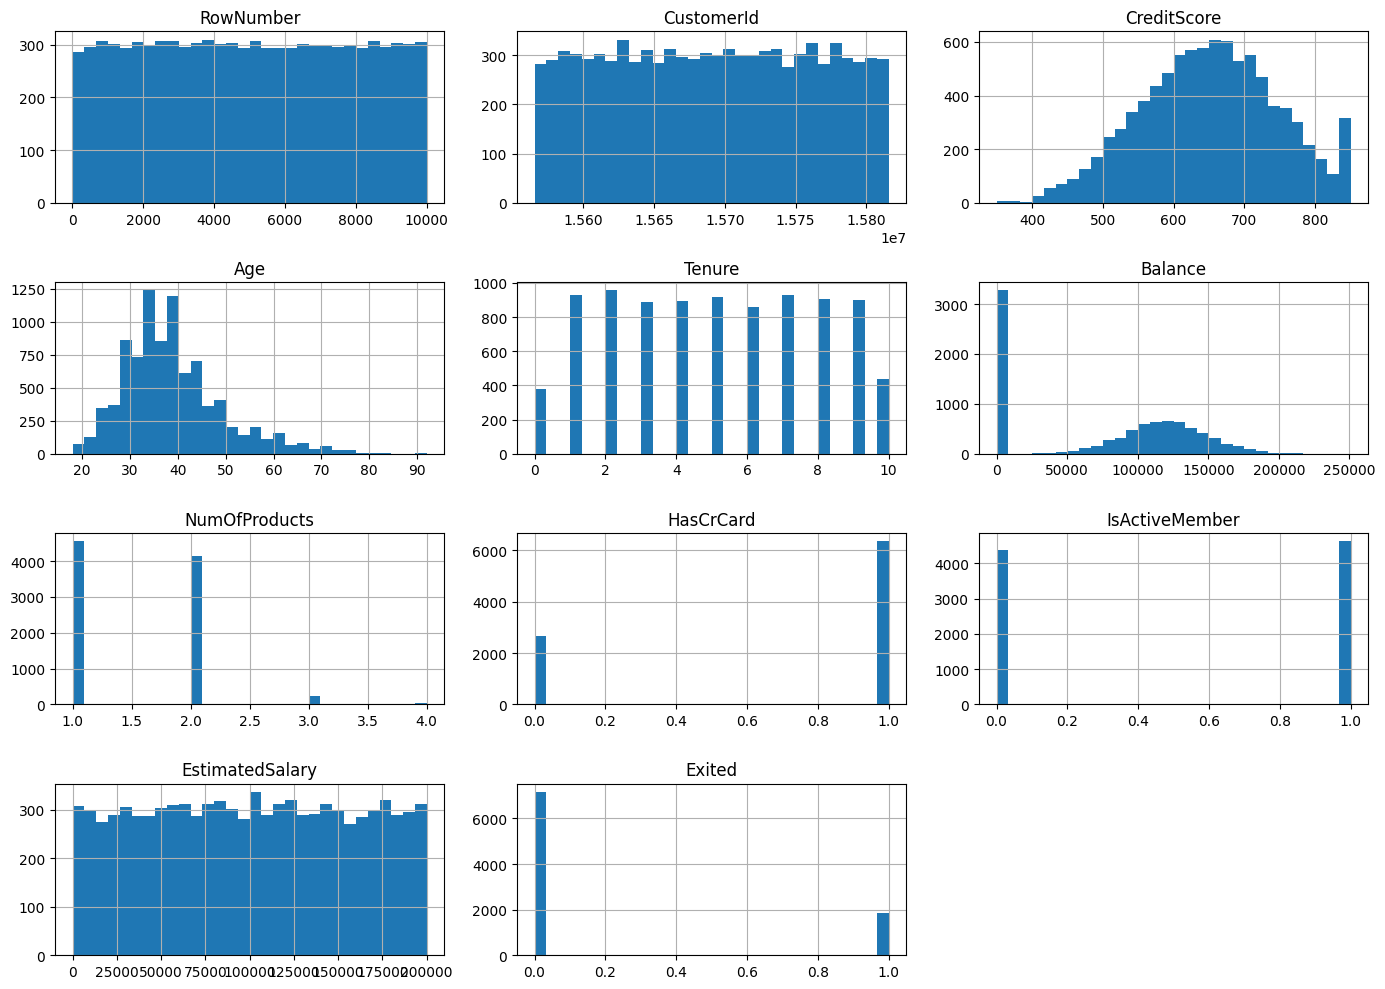


Churn rate by Geography:


Exited,0,1
Geography,,
France,0.838,0.162
Germany,0.673,0.327
Spain,0.833,0.167



Churn rate by Gender:


Exited,0,1
Gender,,
Female,0.748,0.252
Male,0.835,0.165



Average numerical values by target:


,Age,CreditScore,Balance,EstimatedSalary,Tenure
Exited,,,,,
0,37.41,651.87,72536.65,99866.25,5.03
1,44.72,646.04,90565.84,101405.10,4.93


In [7]:
# review numerical variables
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", numerical_cols)

display(df[numerical_cols].describe().T)

df[numerical_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

print("\nChurn rate by Geography:")
display(pd.crosstab(df["Geography"], df["Exited"], normalize="index").round(3))

print("\nChurn rate by Gender:")
display(pd.crosstab(df["Gender"], df["Exited"], normalize="index").round(3))

print("\nAverage numerical values by target:")
display(df.groupby("Exited")[["Age", "CreditScore", "Balance", "EstimatedSalary", "Tenure"]].mean().round(2))

**EDA Conclusions**

From this Exploratory Data Analysis we can retrieve the following information:

* The dataset contains 9,001 rows and 14 columns. Each row represents one bank customer.
* The target variable is `Exited`, which indicates whether the customer left the bank or not.
* The dataset is imbalanced: around 80% of customers did not leave the bank, while around 20% did leave. Because of this, accuracy alone is not enough to evaluate the model.
* There are very few missing values in the dataset, mainly in `Geography`, `Age`, and `HasCrCard`. These missing values can be handled with simple imputation.
* Columns such as `RowNumber`, `CustomerId`, and `Surname` are identifiers, so they should not be used to train the model.
* Geography seems to be relevant because customers from Germany show a higher churn rate.
* Gender also shows some difference, with female customers having a higher churn rate than male customers.
* Age seems to be one of the most important variables, because customers who exited are older on average.
* Active membership is also relevant. Inactive customers are more likely to leave the bank.
* Customers with 3 or 4 products show a very high churn rate, while customers with 2 products are less likely to leave.
* Based on this analysis, the most useful variables for predicting churn may be `Age`, `Geography`, `IsActiveMember`, `NumOfProducts`, `Balance`, and `Gender`.

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [8]:
# Import packages
import os
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

In [9]:
# Load the dataset
df = pd.read_csv("Ejercicio 2.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


In [10]:
# Preprocess the features - create a function for it
def transform(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    # Drop columns that identify customers but do not help the model generalize
    data = data.drop(columns=["RowNumber", "CustomerId", "Surname"], errors="ignore")

    # Fill missing categorical values with the mode
    for col in ["Geography", "Gender"]:
        data[col] = data[col].fillna(data[col].mode()[0])

    # Fill missing numeric/binary values
    data["Age"] = data["Age"].fillna(data["Age"].median())
    data["HasCrCard"] = data["HasCrCard"].fillna(data["HasCrCard"].median())

    # Convert categorical columns into numeric dummy variables
    data = pd.get_dummies(
        data,
        columns=["Geography", "Gender"],
        drop_first=True,
        dtype=int
    )

    return data


processed_df = transform(df)

X = processed_df.drop(columns=["Exited"])
y = processed_df["Exited"]

display(processed_df.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,710,37.0,5,0.00,2,1.0,0.0,115403.31,0,0,0,0
1,569,38.0,8,0.00,2,0.0,0.0,79618.79,0,0,1,1
2,710,54.0,6,171137.62,1,1.0,1.0,167023.95,1,0,0,1
3,673,43.0,8,127132.96,1,0.0,1.0,6009.27,1,0,1,1
4,610,69.0,5,86038.21,3,0.0,0.0,192743.06,1,1,0,0


X shape: (9001, 11)
y shape: (9001,)


In [11]:
# balance the dataset
print("Target distribution:")
display(y.value_counts())
display(y.value_counts(normalize=True).round(3))

# The dataset is imbalanced: most customers did not churn.
# Instead of resampling, we will use class_weight='balanced' in the Decision Tree.

Target distribution:


Exited
0    7161
1    1840
Name: count, dtype: int64

Exited
0    0.796
1    0.204
Name: proportion, dtype: float64

In [12]:
# Train a decision tree model using the train sample
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

params = {
    "max_depth": 5,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "random_state": 42,
    "class_weight": "balanced"
}

dt_model = DecisionTreeClassifier(**params)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [13]:
# Check the accuracy of the model on the test sample
accuracy_value = accuracy_score(y_test, y_pred)
f1_value = f1_score(y_test, y_pred)
precision_value = precision_score(y_test, y_pred)
recall_value = recall_score(y_test, y_pred)

print("Accuracy:", round(accuracy_value, 4))
print("F1 score:", round(f1_value, 4))
print("Precision:", round(precision_value, 4))
print("Recall:", round(recall_value, 4))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

# Save model and feature names for future use
os.makedirs("model_utils", exist_ok=True)

joblib.dump(dt_model, "model_utils/decision_tree_model.pkl")
joblib.dump(list(X_train.columns), "model_utils/feature_columns.pkl")

print("Model and feature columns saved in model_utils/")

Accuracy: 0.6896
F1 score: 0.5126
Precision: 0.3774
Recall: 0.7989

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1433
           1       0.38      0.80      0.51       368

    accuracy                           0.69      1801
   macro avg       0.65      0.73      0.64      1801
weighted avg       0.82      0.69      0.72      1801



,Predicted 0,Predicted 1
Actual 0,948,485
Actual 1,74,294


Model and feature columns saved in model_utils/


### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [15]:
# Import packages for MLflow
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google

Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [16]:
import mlflow

mlflow.end_run()
mlflow.set_tracking_uri("http://127.0.0.1:8080")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: http://127.0.0.1:8080


Visit the MLFlow UI on `http://127.0.0.1:8080`

In [17]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
experiment_name = "Practice Experiment - Nicoputs"
mlflow.set_experiment(experiment_name)

print("Current experiment:", experiment_name)

2026/05/21 02:50:09 INFO mlflow.tracking.fluent: Experiment with name 'Practice Experiment - Nicoputs' does not exist. Creating a new experiment.


Current experiment: Practice Experiment - Nicoputs


In [18]:
# Start an MLflow run
with mlflow.start_run(run_name="decision-tree-baseline") as run:
    
    # Log the hyperparameters
    mlflow.log_params(params)

    # Log the evaluation metrics
    mlflow.log_metric("accuracy", accuracy_value)
    mlflow.log_metric("f1_score", f1_value)
    mlflow.log_metric("precision", precision_value)
    mlflow.log_metric("recall", recall_value)

    # Add a tag to describe the run
    mlflow.set_tag(
        "Training Info",
        "Basic Decision Tree model for customer churn prediction"
    )

    # Infer the model signature
    signature = infer_signature(X_train, dt_model.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=dt_model,
        artifact_path="churn_decision_tree_model",
        signature=signature,
        input_example=X_train.head(5)
    )

    print("Run ID:", run.info.run_id)
    print("Model logged successfully")

/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run ID: fa92e01865e14a9fb4d352285841dd15
Model logged successfully
🏃 View run decision-tree-baseline at: http://127.0.0.1:8080/#/experiments/1/runs/fa92e01865e14a9fb4d352285841dd15
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/1


### Keep practicing

In [ ]:
# Create a new experiment using other models or different parameters

practice_experiment_name = "Keep Practicing - Nico"
mlflow.set_experiment(practice_experiment_name)

practice_models = {
    "decision-tree-deeper": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=30,
        min_samples_leaf=15,
        random_state=42,
        class_weight="balanced"
    ),
    "random-forest-balanced": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced"
    )
}

practice_results = []

for run_name, model in practice_models.items():
    
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    practice_results.append({
        "model": run_name,
        "accuracy": round(acc, 4),
        "f1_score": round(f1, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4)
    })

    with mlflow.start_run(run_name=run_name):
        
        mlflow.log_params(model.get_params())
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)

        mlflow.set_tag(
            "Training Info",
            "Practice run using a different model or different hyperparameters"
        )

        signature = infer_signature(X_train, model.predict(X_train))

        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path=run_name,
            signature=signature,
            input_example=X_train.head(5)
        )

practice_results_df = pd.DataFrame(practice_results)
display(practice_results_df)

2026/05/21 02:50:39 INFO mlflow.tracking.fluent: Experiment with name 'Keep Practicing - Nicoputs' does not exist. Creating a new experiment.
/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run decision-tree-deeper at: http://127.0.0.1:8080/#/experiments/2/runs/5c8d1213d273425bb0c2c5e41a3056ae
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


/Users/nicoputs/Desktop/mlops-and-system-design-main/mlops-and-system-design/.venv/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run random-forest-balanced at: http://127.0.0.1:8080/#/experiments/2/runs/2db087c0a5754a04b1f98fc9d78bdd15
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/2


,model,accuracy,f1_score,precision,recall
0,decision-tree-deeper,0.7440,0.5422,0.4272,0.7418
1,random-forest-balanced,0.8101,0.5986,0.5269,0.6929
